   Customer Id First Name Last Name                    Company  \
0            1    Rebecca    Hoover                Bowen Group   
1            2      James    Dawson             Solis-Thompson   
2            3      Keith  Williams               Lawrence Inc   
3            4        Ian   Hawkins  English, Jordan and Evans   
4            5    Richard      Cruz  Davidson, Baker and Brown   

                 City   Country             Phone 1                 Email  \
0       South Zachary     Ghana        449.871.2249  mathew37@hotmail.com   
1  New Stephenchester    Sweden       (512)481-6439     cowens@steele.com   
2      North Jeremiah  Pakistan  (073)484-8560x4111   donna82@hotmail.com   
3        Johnsonhaven  Guernsey        936.638.7121    ashley60@yahoo.com   
4          South Erin    Brazil        180.534.2116    kray@carpenter.biz   

  Subscription Date  Salary  Age  
0        2024-05-05  114670   33  
1        2026-04-11   78947   57  
2        2023-01-07  102454   39  


/tmp/ipykernel_7595/677845774.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
/tmp/ipykernel_7595/677845774.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

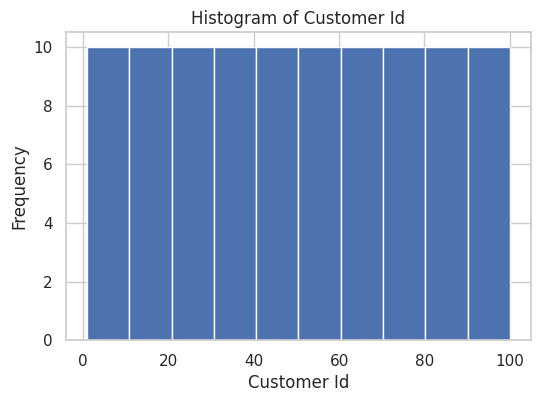

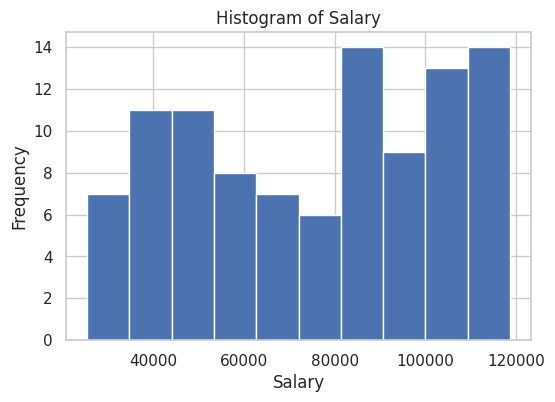

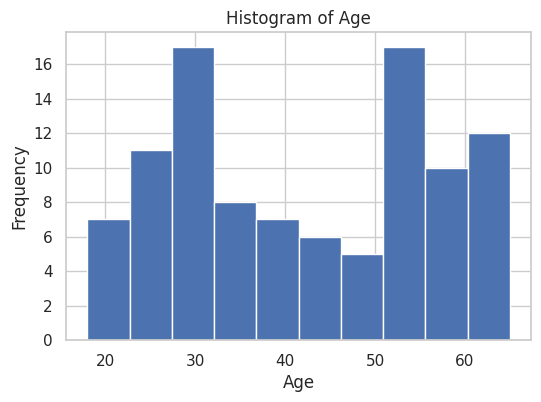

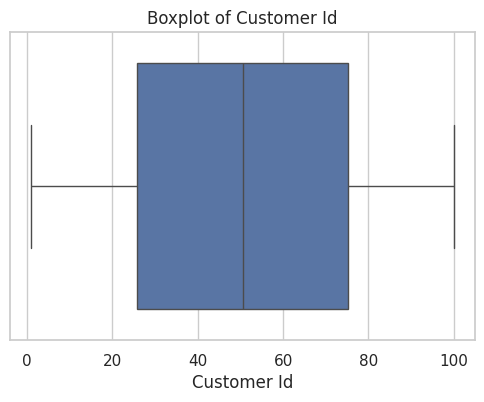

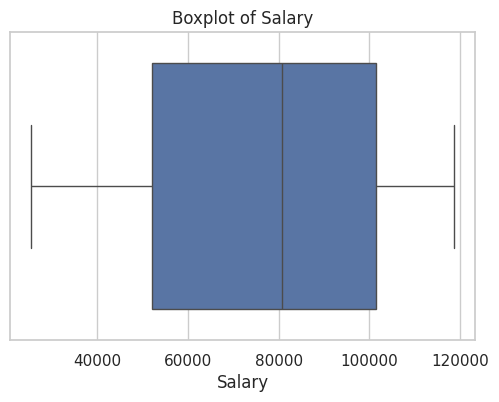

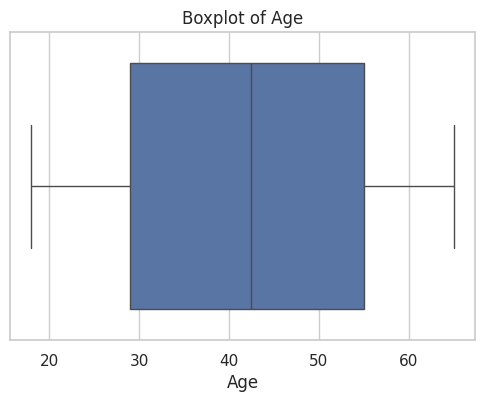

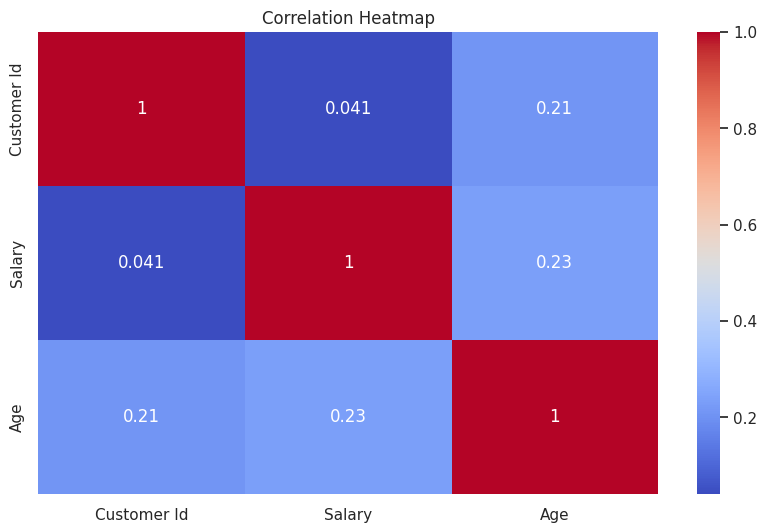

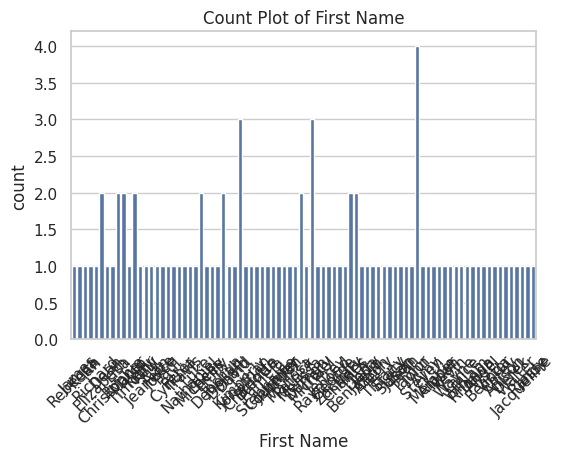

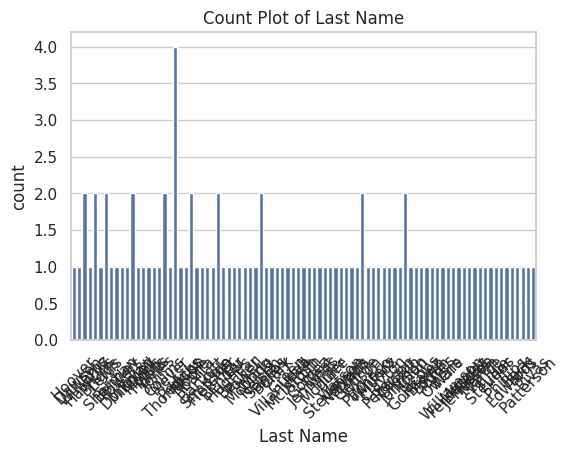

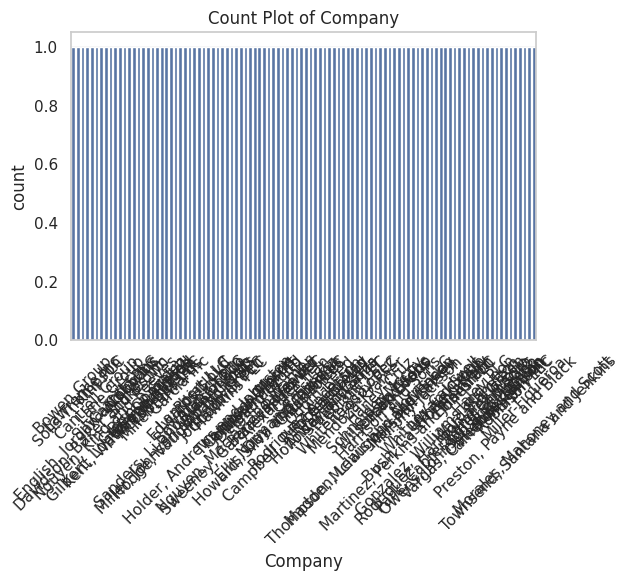

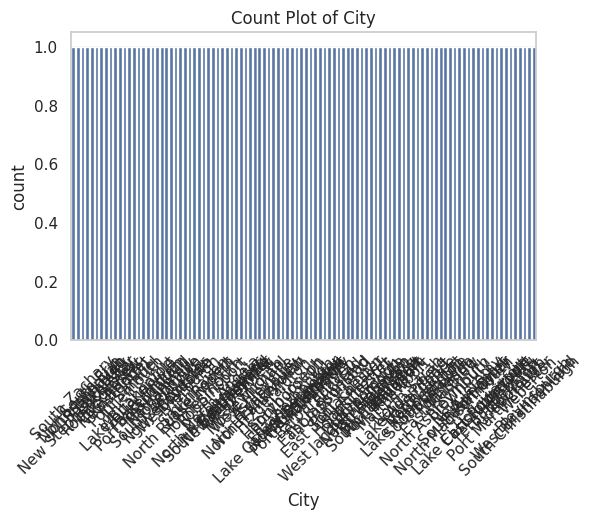

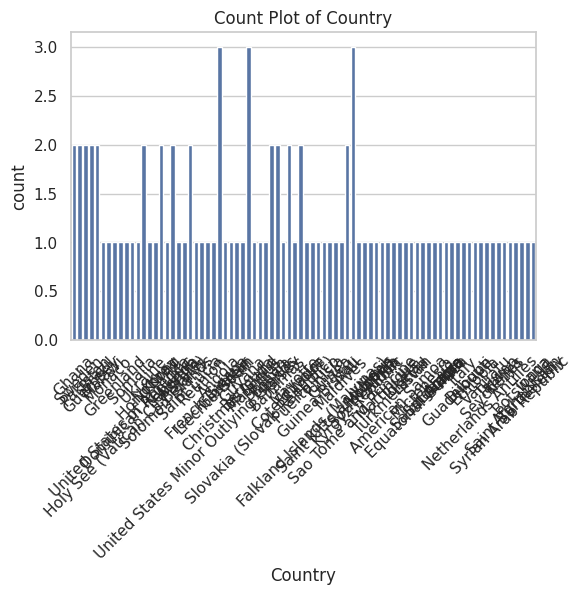

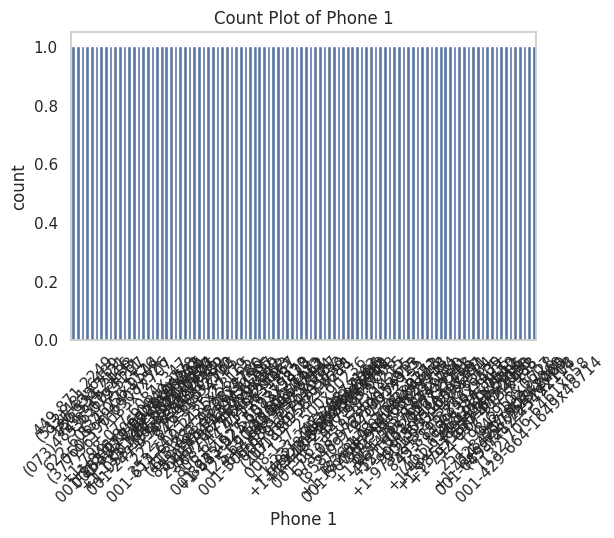

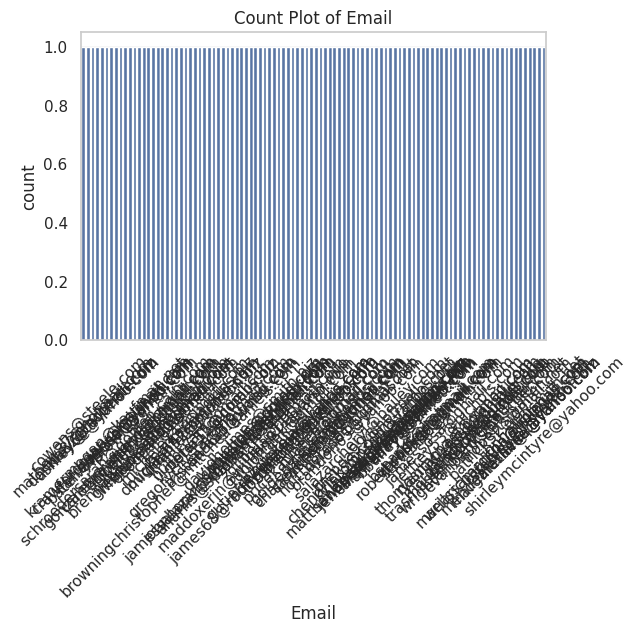

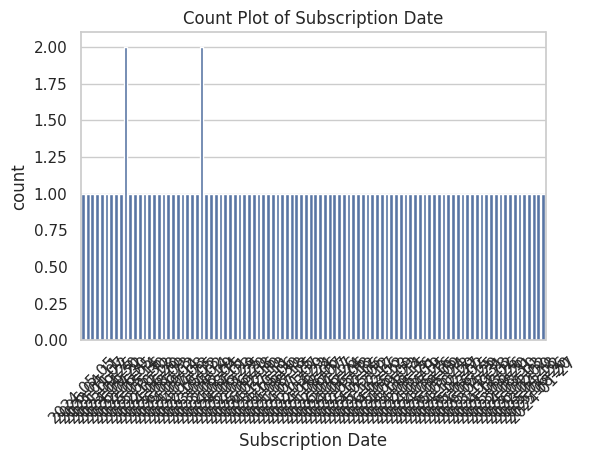

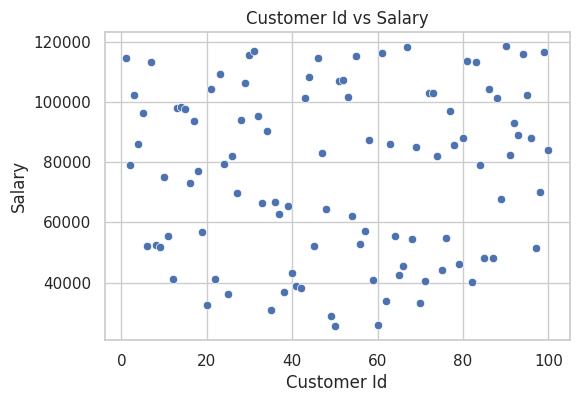

Average Customer Id : 50.5
Maximum Customer Id : 100
Minimum Customer Id : 1
Average Salary : 76163.31
Maximum Salary : 118588
Minimum Salary : 25458
Average Age : 42.26
Maximum Age : 65
Minimum Age : 18
   Customer Id First Name Last Name                    Company  \
0            1    Rebecca    Hoover                Bowen Group   
1            2      James    Dawson             Solis-Thompson   
2            3      Keith  Williams               Lawrence Inc   
3            4        Ian   Hawkins  English, Jordan and Evans   
4            5    Richard      Cruz  Davidson, Baker and Brown   

                 City   Country             Phone 1                 Email  \
0       South Zachary     Ghana        449.871.2249  mathew37@hotmail.com   
1  New Stephenchester    Sweden       (512)481-6439     cowens@steele.com   
2      North Jeremiah  Pakistan  (073)484-8560x4111   donna82@hotmail.com   
3        Johnsonhaven  Guernsey        936.638.7121    ashley60@yahoo.com   
4          Sou

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/customers-100.csv")

print(df.head())
print(df.shape)
print(df.columns)

print(df.info())
print(df.describe())

print(df.isnull().sum())

numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    df[col].fillna(df[col].mean(), inplace=True)

categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

print(df.isnull().sum())

print(df.duplicated().sum())

df.drop_duplicates(inplace=True)

for col in numeric_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df = df[
        (df[col] >= lower_limit) &
        (df[col] <= upper_limit)
    ]

df.to_csv("cleaned_data.csv", index=False)

sns.set(style="whitegrid")

for col in numeric_columns:

    plt.figure(figsize=(6,4))

    plt.hist(df[col], bins=10)

    plt.title(f"Histogram of {col}")

    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.show()

for col in numeric_columns:

    plt.figure(figsize=(6,4))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col}")

    plt.show()

plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

for col in categorical_columns:

    plt.figure(figsize=(6,4))

    sns.countplot(x=df[col])

    plt.title(f"Count Plot of {col}")

    plt.xticks(rotation=45)

    plt.show()

if len(numeric_columns) >= 2:

    plt.figure(figsize=(6,4))

    sns.scatterplot(
        x=numeric_columns[0],
        y=numeric_columns[1],
        data=df
    )

    plt.title(
        f"{numeric_columns[0]} vs {numeric_columns[1]}"
    )

    plt.show()

for col in numeric_columns:

    print(f"Average {col} :", df[col].mean())
    print(f"Maximum {col} :", df[col].max())
    print(f"Minimum {col} :", df[col].min())

print(df.head())
print(df.shape)

print("DATA CLEANING & VISUALIZATION DONE")